In [ ]:
fraud_detection.ipynb


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot styling
sns.set_style("whitegrid")

# Load datasets
train_df = pd.read_csv('../data/fraudTrain.csv')
test_df = pd.read_csv('../data/fraudTest.csv')

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (1296675, 23)
Testing Dataset Shape: (555719, 23)


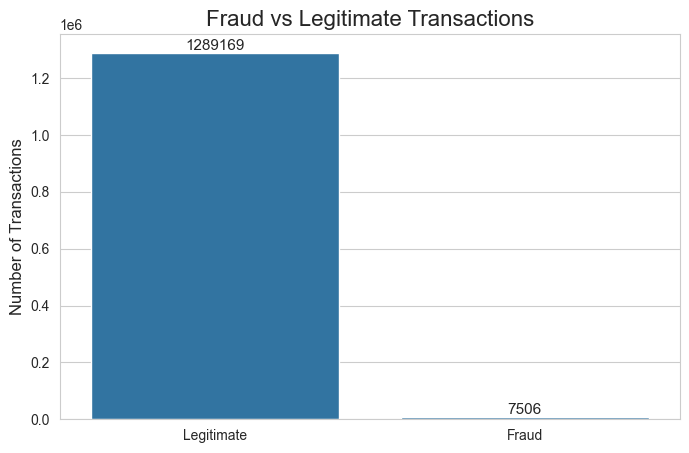

In [2]:
# Fraud distribution
fraud_counts = train_df['is_fraud'].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=['Legitimate', 'Fraud'],
    y=fraud_counts.values
)

plt.title('Fraud vs Legitimate Transactions', fontsize=16)
plt.ylabel('Number of Transactions', fontsize=12)

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()


In [3]:
# Calculate fraud percentages
fraud_percentage = (fraud_counts[1] / len(train_df)) * 100
legit_percentage = (fraud_counts[0] / len(train_df)) * 100

print(f"Legitimate Transactions: {legit_percentage:.4f}%")
print(f"Fraudulent Transactions: {fraud_percentage:.4f}%")

Legitimate Transactions: 99.4211%
Fraudulent Transactions: 0.5789%


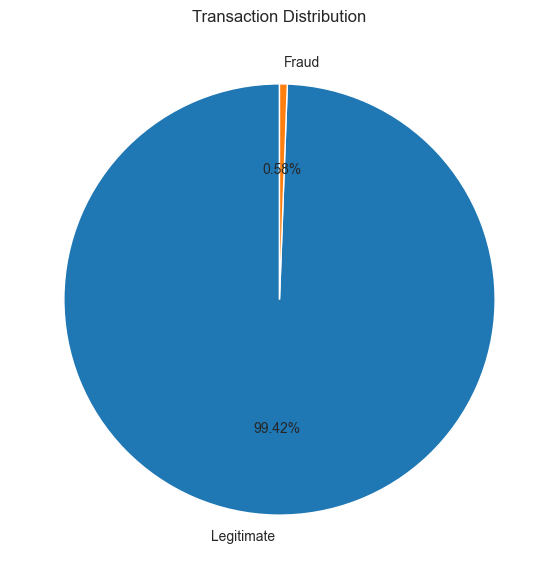

In [4]:
labels = ['Legitimate', 'Fraud']
sizes = [fraud_counts[0], fraud_counts[1]]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Transaction Distribution')

plt.show()

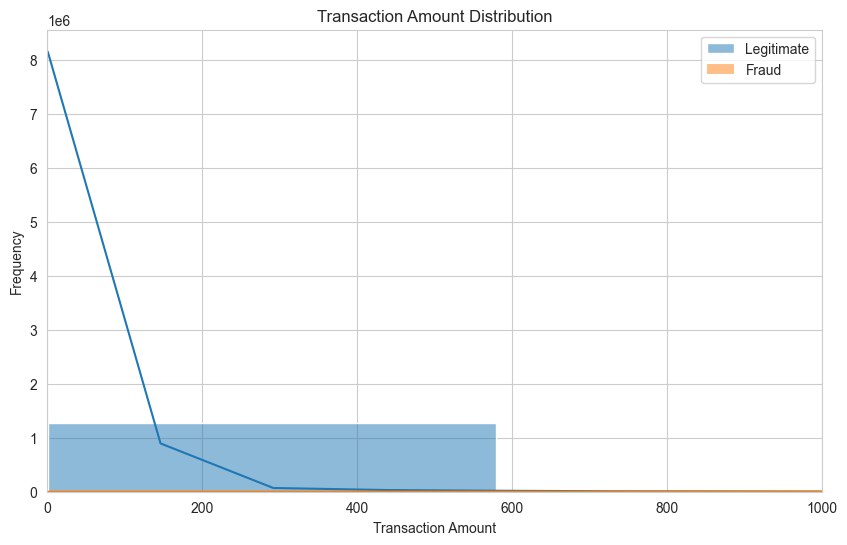

In [5]:
# Separate fraud and legitimate transactions
fraud_transactions = train_df[train_df['is_fraud'] == 1]
legit_transactions = train_df[train_df['is_fraud'] == 0]

# Plot transaction amount distributions
plt.figure(figsize=(10,6))

sns.histplot(
    legit_transactions['amt'],
    bins=50,
    label='Legitimate',
    kde=True
)

sns.histplot(
    fraud_transactions['amt'],
    bins=50,
    label='Fraud',
    kde=True
)

plt.xlim(0, 1000)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.legend()

plt.show()

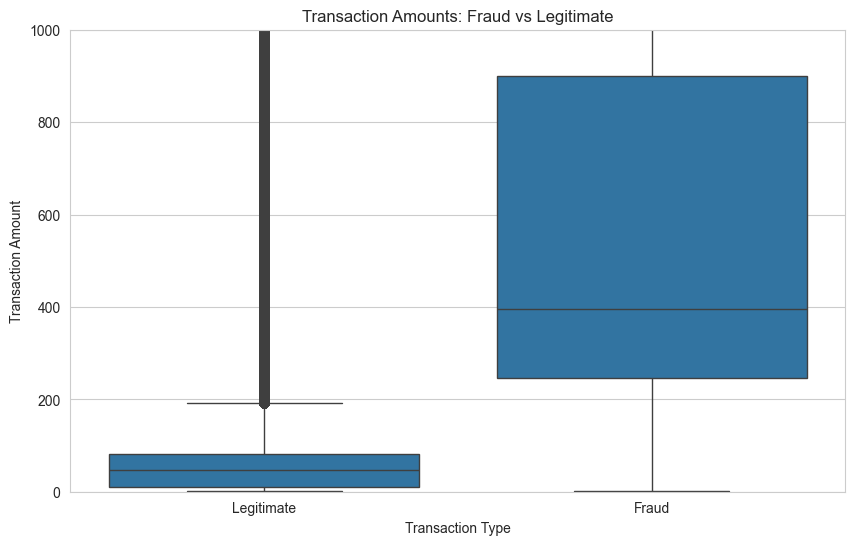

In [6]:
# Compare transaction amounts using boxplots

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='amt',
    data=train_df
)

plt.title('Transaction Amounts: Fraud vs Legitimate')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')

plt.xticks([0,1], ['Legitimate', 'Fraud'])

plt.ylim(0, 1000)

plt.show()

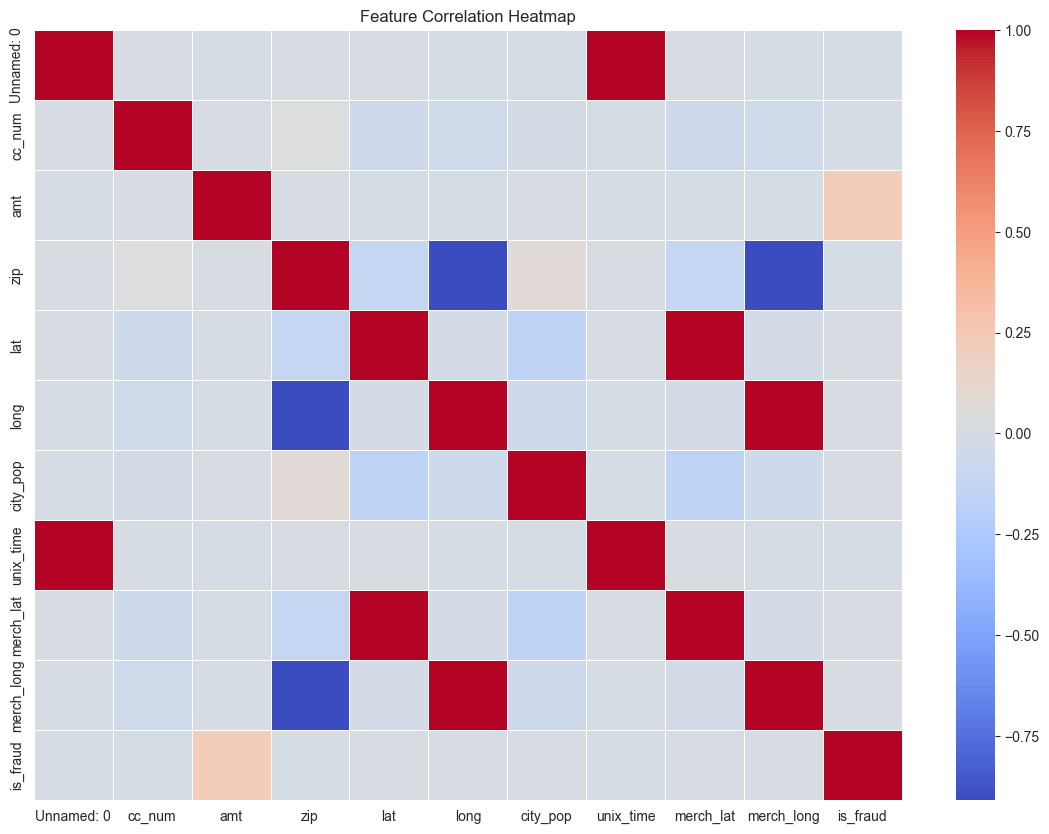

In [7]:
# Select only numerical columns
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [8]:
from math import radians, sin, cos, sqrt, atan2

In [9]:
# Function to calculate geographic distance

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2)**2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [10]:
# Create distance feature

train_df['distance_km'] = train_df.apply(
    lambda row: haversine(
        row['lat'],
        row['long'],
        row['merch_lat'],
        row['merch_long']
    ),
    axis=1
)

print(train_df['distance_km'].head())

0     78.597568
1     30.212176
2    108.206083
3     95.673231
4     77.556744
Name: distance_km, dtype: float64


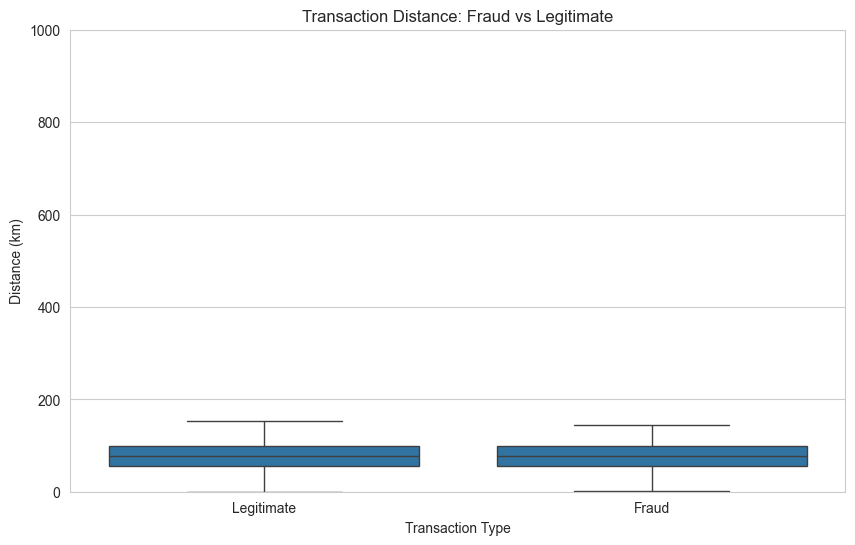

In [11]:
# Compare distance distributions

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='distance_km',
    data=train_df
)

plt.title('Transaction Distance: Fraud vs Legitimate')
plt.xlabel('Transaction Type')
plt.ylabel('Distance (km)')

plt.xticks([0,1], ['Legitimate', 'Fraud'])

plt.ylim(0, 1000)

plt.show()


In [12]:
# Convert transaction time to datetime

train_df['trans_date_trans_time'] = pd.to_datetime(
    train_df['trans_date_trans_time']
)

# Extract useful time features
train_df['hour'] = train_df['trans_date_trans_time'].dt.hour
train_df['day_of_week'] = train_df['trans_date_trans_time'].dt.dayofweek

# Preview
print(
    train_df[
        ['trans_date_trans_time', 'hour', 'day_of_week']
    ].head()
)

  trans_date_trans_time  hour  day_of_week
0   2019-01-01 00:00:18     0            1
1   2019-01-01 00:00:44     0            1
2   2019-01-01 00:00:51     0            1
3   2019-01-01 00:01:16     0            1
4   2019-01-01 00:03:06     0            1


In [13]:
# Fraud transactions by hour

fraud_by_hour = (
    train_df[train_df['is_fraud'] == 1]
    .groupby('hour')
    .size()
)

print(fraud_by_hour)

hour
0      635
1      658
2      625
3      609
4       46
5       60
6       40
7       56
8       49
9       47
10      40
11      42
12      67
13      80
14      86
15      79
16      76
17      78
18      81
19      81
20      62
21      74
22    1931
23    1904
dtype: int64


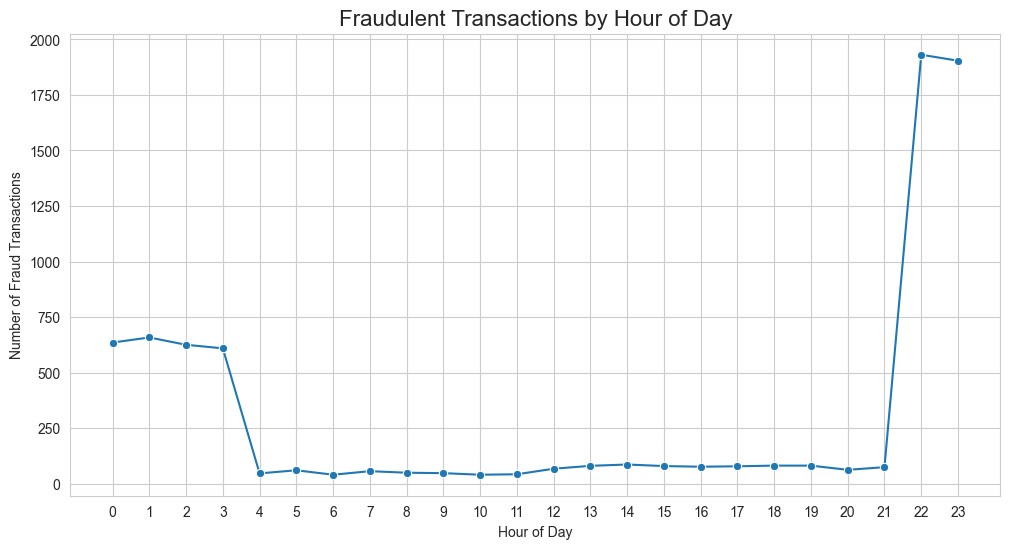

In [14]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values,
    marker='o'
)

plt.title('Fraudulent Transactions by Hour of Day', fontsize=16)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraud Transactions')

plt.xticks(range(0,24))

plt.show()

In [ ]:
## Fraud Activity by Hour - Observations

Fraudulent transactions show strong temporal patterns, with major spikes occurring during late-night hours (22:00–03:00).

This suggests that fraudulent activity is not randomly distributed throughout the day and may exploit periods of lower user activity or reduced monitoring.

Such temporal behavior can become an important predictive signal in fraud detection systems.

In [16]:
# Drop unnecessary columns

columns_to_drop = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'first',
    'last',
    'street',
    'city',
    'state',
    'job',
    'dob',
    'trans_num'
]

train_df = train_df.drop(columns=columns_to_drop)

print(train_df.columns)

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'zip', 'lat', 'long',
       'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'distance_km', 'hour', 'day_of_week'],
      dtype='object')


In [17]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
le_merchant = LabelEncoder()
le_category = LabelEncoder()
le_gender = LabelEncoder()

# Encode categorical columns
train_df['merchant'] = le_merchant.fit_transform(train_df['merchant'])

train_df['category'] = le_category.fit_transform(train_df['category'])

train_df['gender'] = le_gender.fit_transform(train_df['gender'])

# Preview encoded data
print(
    train_df[
        ['merchant', 'category', 'gender']
    ].head()
)

   merchant  category  gender
0       514         8       0
1       241         4       0
2       390         0       1
3       360         2       1
4       297         9       1


In [18]:
# Features and target

X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1296675, 15)
Target Shape: (1296675,)


In [19]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1037340, 15)
Testing Set: (259335, 15)


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
# Generate predictions

y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [22]:
from sklearn.metrics import classification_report

# Classification metrics
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.95      0.68      0.79      1501

    accuracy                           1.00    259335
   macro avg       0.97      0.84      0.90    259335
weighted avg       1.00      1.00      1.00    259335



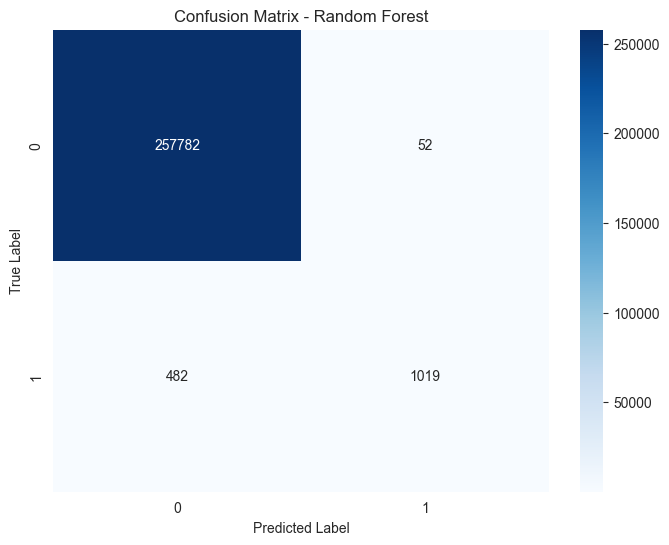

In [23]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [24]:
# Improved Random Forest with class balancing

balanced_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Train model
balanced_rf.fit(X_train, y_train)

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [25]:
# Predictions from balanced model

balanced_pred = balanced_rf.predict(X_test)

# Classification report
print(
    classification_report(
        y_test,
        balanced_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.95      0.67      0.79      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.83      0.89    259335
weighted avg       1.00      1.00      1.00    259335



In [26]:
# Fraud probabilities

y_probs = rf_model.predict_proba(X_test)[:, 1]

print(y_probs[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


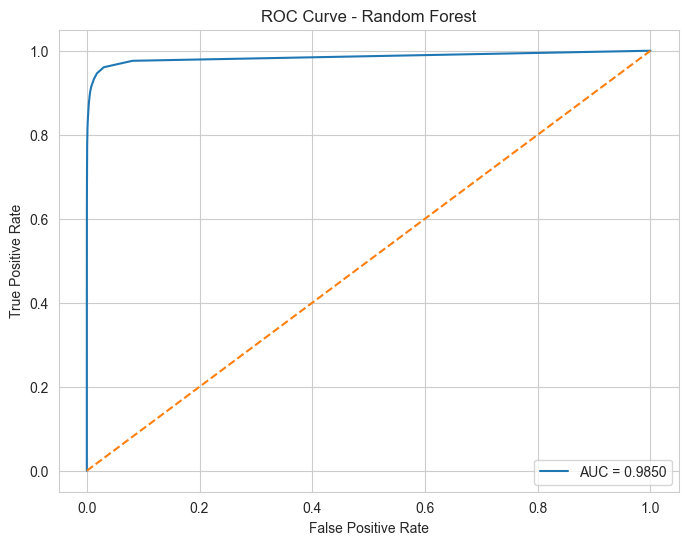

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC score
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

# SAVE IMAGE
plt.savefig('../images/roc_curve.png', bbox_inches='tight')

plt.show()

In [28]:
# Lower fraud threshold

custom_threshold = 0.30

custom_pred = (y_probs >= custom_threshold).astype(int)

print(custom_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [29]:
# Classification report with custom threshold

print(
    classification_report(
        y_test,
        custom_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.86      0.79      0.82      1501

    accuracy                           1.00    259335
   macro avg       0.93      0.89      0.91    259335
weighted avg       1.00      1.00      1.00    259335



In [30]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

        Feature  Importance
3           amt    0.405319
2      category    0.135769
13         hour    0.097115
9     unix_time    0.044105
8      city_pop    0.037787
10    merch_lat    0.037751
11   merch_long    0.037521
12  distance_km    0.035675
1      merchant    0.032028
0        cc_num    0.030101


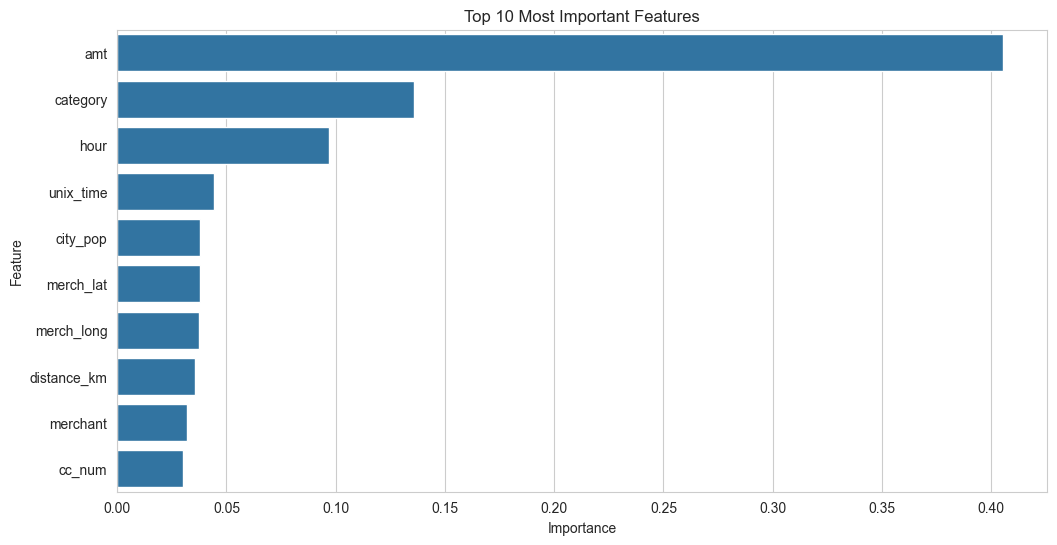

In [40]:
# Plot feature importance

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Most Important Features')

# SAVE IMAGE
plt.savefig('../images/feature_importance.png', bbox_inches='tight')

plt.show()

In [32]:
import shap

In [33]:
# Create SHAP explainer

explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [34]:
# Sample subset for SHAP analysis
sample_X = X_test.sample(1000, random_state=42)

# Generate SHAP values
shap_values = explainer.shap_values(sample_X)

print("SHAP values generated successfully.")

SHAP values generated successfully.


In [36]:
print(type(shap_values))
print(len(shap_values))

print(shap_values[0].shape)
print(sample_X.shape)

<class 'numpy.ndarray'>
1000
(15, 2)
(1000, 15)


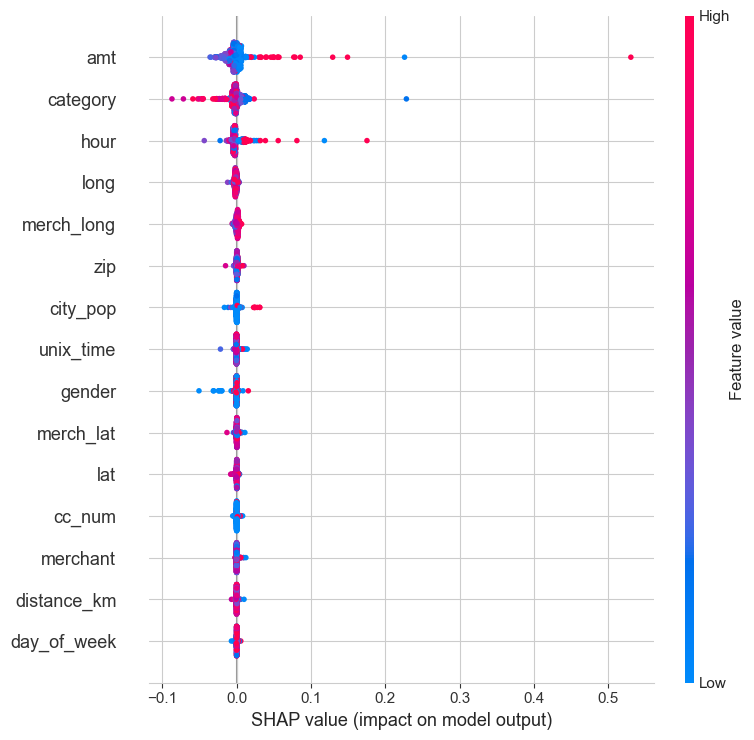

In [41]:
# SHAP summary plot

shap.summary_plot(
    shap_values[:, :, 1],
    sample_X,
    show=False
)

# SAVE IMAGE
plt.savefig('../images/shap_summary.png', bbox_inches='tight')

plt.show()